### Assignment 1 (4 scores):

- Use Numpy only to construct the Logistic Regression model.
- Train that Logistic Regression model dataset using the Gradient Descend approach on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset. *Note that three class in this dataset must be merge into two class as: graduate and non-graduate (dropout or enroll)*.
- Evaluate that Logistic Regression model on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.
- Visualize the loss function of the training process.

In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('data.csv', delimiter= ';')

In [5]:
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [6]:
df.dtypes

Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance\t                        int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

In [7]:
df.head(10)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
5,2,39,1,9991,0,19,133.1,1,37,37,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,Graduate
6,1,1,1,9500,1,1,142.0,1,19,38,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,Graduate
7,1,18,4,9254,1,1,119.0,1,37,37,...,0,5,5,0,0.000000,0,15.5,2.8,-4.06,Dropout
8,1,1,3,9238,1,1,137.0,62,1,1,...,0,6,7,6,14.142857,0,16.2,0.3,-0.92,Graduate
9,1,1,1,9238,1,1,138.0,1,1,19,...,0,6,14,2,13.500000,0,8.9,1.4,3.51,Dropout


# Preprocessing Data

In [8]:
# Checking for missing values
for column in df.columns:
    print(f'{column}')
    print(f'IsNA: {df[column].isna().sum()}')
    print(f'IsNULL: {df[column].isnull().sum()}')
    print(f'Data Type: {df[column].dtypes}')
    print('\n')

Marital status
IsNA: 0
IsNULL: 0
Data Type: int64


Application mode
IsNA: 0
IsNULL: 0
Data Type: int64


Application order
IsNA: 0
IsNULL: 0
Data Type: int64


Course
IsNA: 0
IsNULL: 0
Data Type: int64


Daytime/evening attendance	
IsNA: 0
IsNULL: 0
Data Type: int64


Previous qualification
IsNA: 0
IsNULL: 0
Data Type: int64


Previous qualification (grade)
IsNA: 0
IsNULL: 0
Data Type: float64


Nacionality
IsNA: 0
IsNULL: 0
Data Type: int64


Mother's qualification
IsNA: 0
IsNULL: 0
Data Type: int64


Father's qualification
IsNA: 0
IsNULL: 0
Data Type: int64


Mother's occupation
IsNA: 0
IsNULL: 0
Data Type: int64


Father's occupation
IsNA: 0
IsNULL: 0
Data Type: int64


Admission grade
IsNA: 0
IsNULL: 0
Data Type: float64


Displaced
IsNA: 0
IsNULL: 0
Data Type: int64


Educational special needs
IsNA: 0
IsNULL: 0
Data Type: int64


Debtor
IsNA: 0
IsNULL: 0
Data Type: int64


Tuition fees up to date
IsNA: 0
IsNULL: 0
Data Type: int64


Gender
IsNA: 0
IsNULL: 0
Data Type: int64


Sch

In [9]:
# Encode "Target" into two class: Graduate-1 and Non-graduate-0
def encode_target(target: str) ->int:
    if target == 'Graduate':
        return 1
    if target == 'Dropout' or target == 'Enrolled':
        return 0
        

In [10]:
df['Target'] = df['Target'].apply(encode_target)


In [11]:
df.head(10)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,1
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,1
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,1
5,2,39,1,9991,0,19,133.1,1,37,37,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,1
6,1,1,1,9500,1,1,142.0,1,19,38,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,1
7,1,18,4,9254,1,1,119.0,1,37,37,...,0,5,5,0,0.000000,0,15.5,2.8,-4.06,0
8,1,1,3,9238,1,1,137.0,62,1,1,...,0,6,7,6,14.142857,0,16.2,0.3,-0.92,1
9,1,1,1,9238,1,1,138.0,1,1,19,...,0,6,14,2,13.500000,0,8.9,1.4,3.51,0


In [12]:
df.isna().sum(axis = 0)

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [13]:
for column in df.columns:
    print(f'{column}\n\tMin: {df[column].min()}\n\tMax: {df[column].max()}')

Marital status
	Min: 1
	Max: 6
Application mode
	Min: 1
	Max: 57
Application order
	Min: 0
	Max: 9
Course
	Min: 33
	Max: 9991
Daytime/evening attendance	
	Min: 0
	Max: 1
Previous qualification
	Min: 1
	Max: 43
Previous qualification (grade)
	Min: 95.0
	Max: 190.0
Nacionality
	Min: 1
	Max: 109
Mother's qualification
	Min: 1
	Max: 44
Father's qualification
	Min: 1
	Max: 44
Mother's occupation
	Min: 0
	Max: 194
Father's occupation
	Min: 0
	Max: 195
Admission grade
	Min: 95.0
	Max: 190.0
Displaced
	Min: 0
	Max: 1
Educational special needs
	Min: 0
	Max: 1
Debtor
	Min: 0
	Max: 1
Tuition fees up to date
	Min: 0
	Max: 1
Gender
	Min: 0
	Max: 1
Scholarship holder
	Min: 0
	Max: 1
Age at enrollment
	Min: 17
	Max: 70
International
	Min: 0
	Max: 1
Curricular units 1st sem (credited)
	Min: 0
	Max: 20
Curricular units 1st sem (enrolled)
	Min: 0
	Max: 26
Curricular units 1st sem (evaluations)
	Min: 0
	Max: 45
Curricular units 1st sem (approved)
	Min: 0
	Max: 26
Curricular units 1st sem (grade)
	Min: 0.

# Normalizing Data

In [14]:
# Select continuous features
continuous_columns = [
    "Previous qualification (grade)",
    "Admission grade",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]
# Normalize continuous features
for column in continuous_columns:
    df[column] = (df[column] - df[column].mean()) / df[column].std()

In [15]:
df.head(5)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,-0.804750,1,19,12,...,0,0,0,0,0.000000,0,-0.287606,0.124372,0.765674,0
1,1,15,1,9254,1,1,2.076585,1,1,3,...,0,6,6,6,13.666667,0,0.876123,-1.105097,0.347160,1
2,1,1,5,9070,1,1,-0.804750,1,37,37,...,0,6,0,0,0.000000,0,-0.287606,0.124372,0.765674,0
3,1,17,2,9773,1,1,-0.804750,1,38,37,...,0,6,10,5,12.400000,0,-0.813161,-1.466705,-1.375356,1
4,2,39,1,8014,0,1,-2.472892,1,37,38,...,0,6,6,6,13.000000,0,0.876123,-1.105097,0.347160,1


# Visualize data

In [16]:
from matplotlib import pyplot as plt
import seaborn as sns

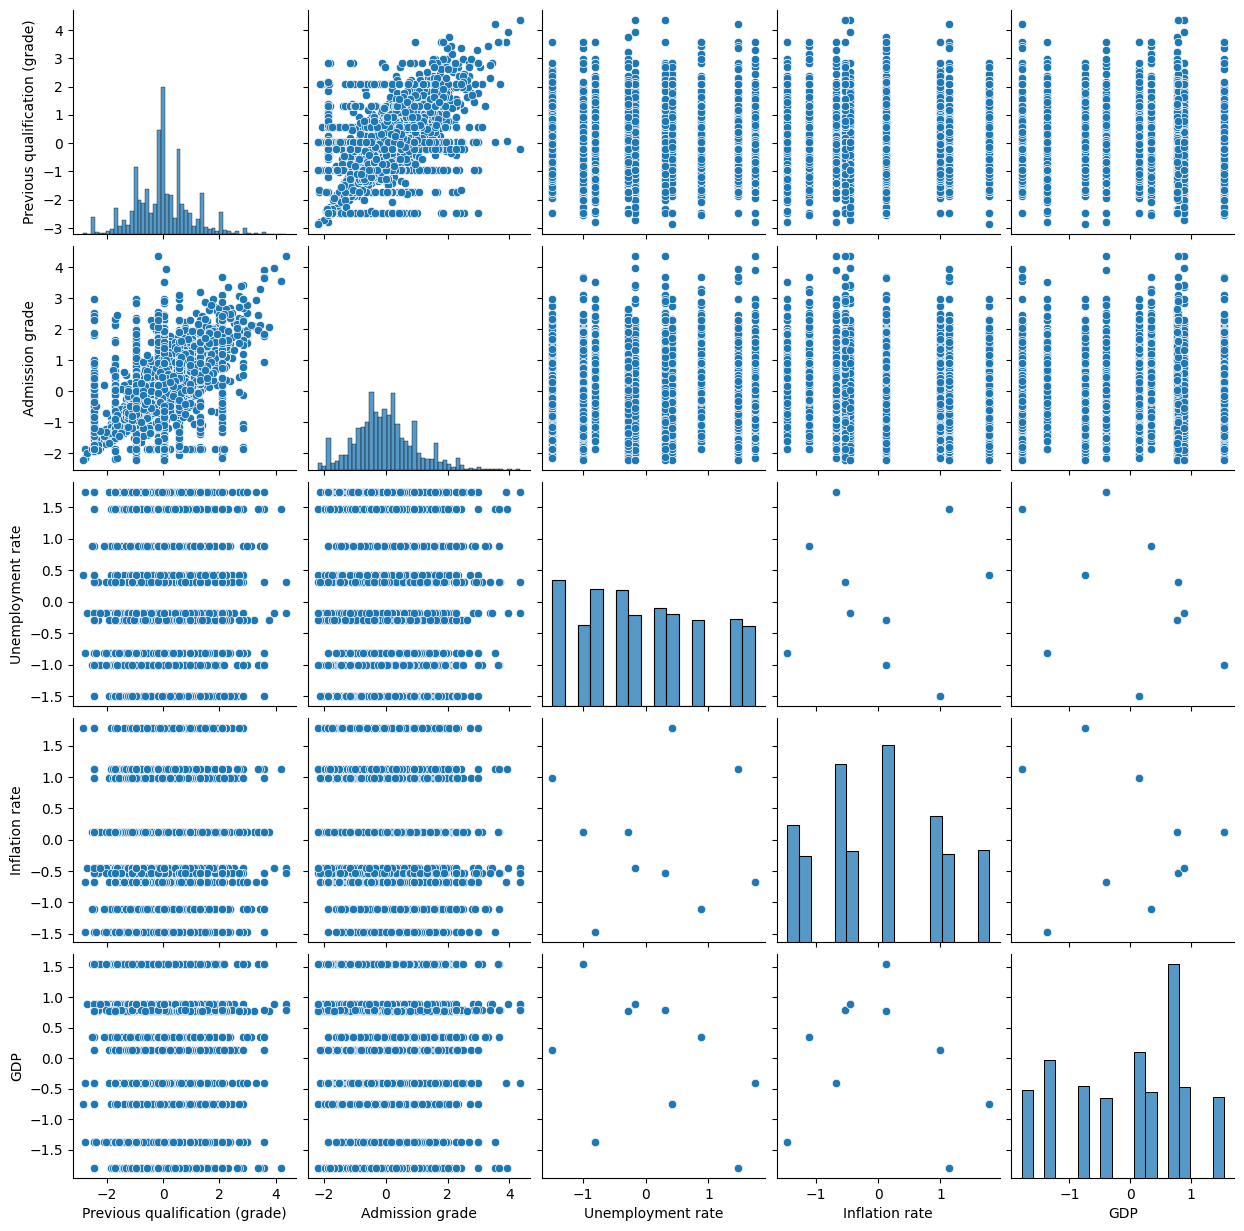

In [17]:
sns.pairplot(df[continuous_columns])
plt.show()

# Feature Engineering

In [18]:
# Search for discrete features
dicrete_columns = [column for column in df.columns if column not in continuous_columns]

In [19]:
num_features = len(df.columns) - 1

# Create correlation matrix (n x n)
cov = np.zeros((num_features, num_features))

# Calculate correlation matrix
for i, col_i in enumerate(df.columns[:-1]):
    for j, col_j in enumerate(df.columns[: -1]):
        cov[i, j] = np.corrcoef(df[col_i].to_numpy(), df[col_j].to_numpy())[0, 1]
        
print('Correlation matrix:\n',cov)



Correlation matrix:
 [[ 1.          0.26400582 -0.12585445 ... -0.02033757  0.00876135
  -0.02700341]
 [ 0.26400582  1.         -0.28635726 ...  0.08908008 -0.01637463
  -0.02274272]
 [-0.12585445 -0.28635726  1.         ... -0.09841917 -0.01113321
   0.03020082]
 ...
 [-0.02033757  0.08908008 -0.09841917 ...  1.         -0.02888466
  -0.33517812]
 [ 0.00876135 -0.01637463 -0.01113321 ... -0.02888466  1.
  -0.11229464]
 [-0.02700341 -0.02274272  0.03020082 ... -0.33517812 -0.11229464
   1.        ]]


/Users/nanhs/Documents/2nd_Semester(2024-2024)/DS102_StatisticalMachineLearning/Lab_02/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()


<Axes: >

/Users/nanhs/Documents/2nd_Semester(2024-2024)/DS102_StatisticalMachineLearning/Lab_02/.venv/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/nanhs/Documents/2nd_Semester(2024-2024)/DS102_StatisticalMachineLearning/Lab_02/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


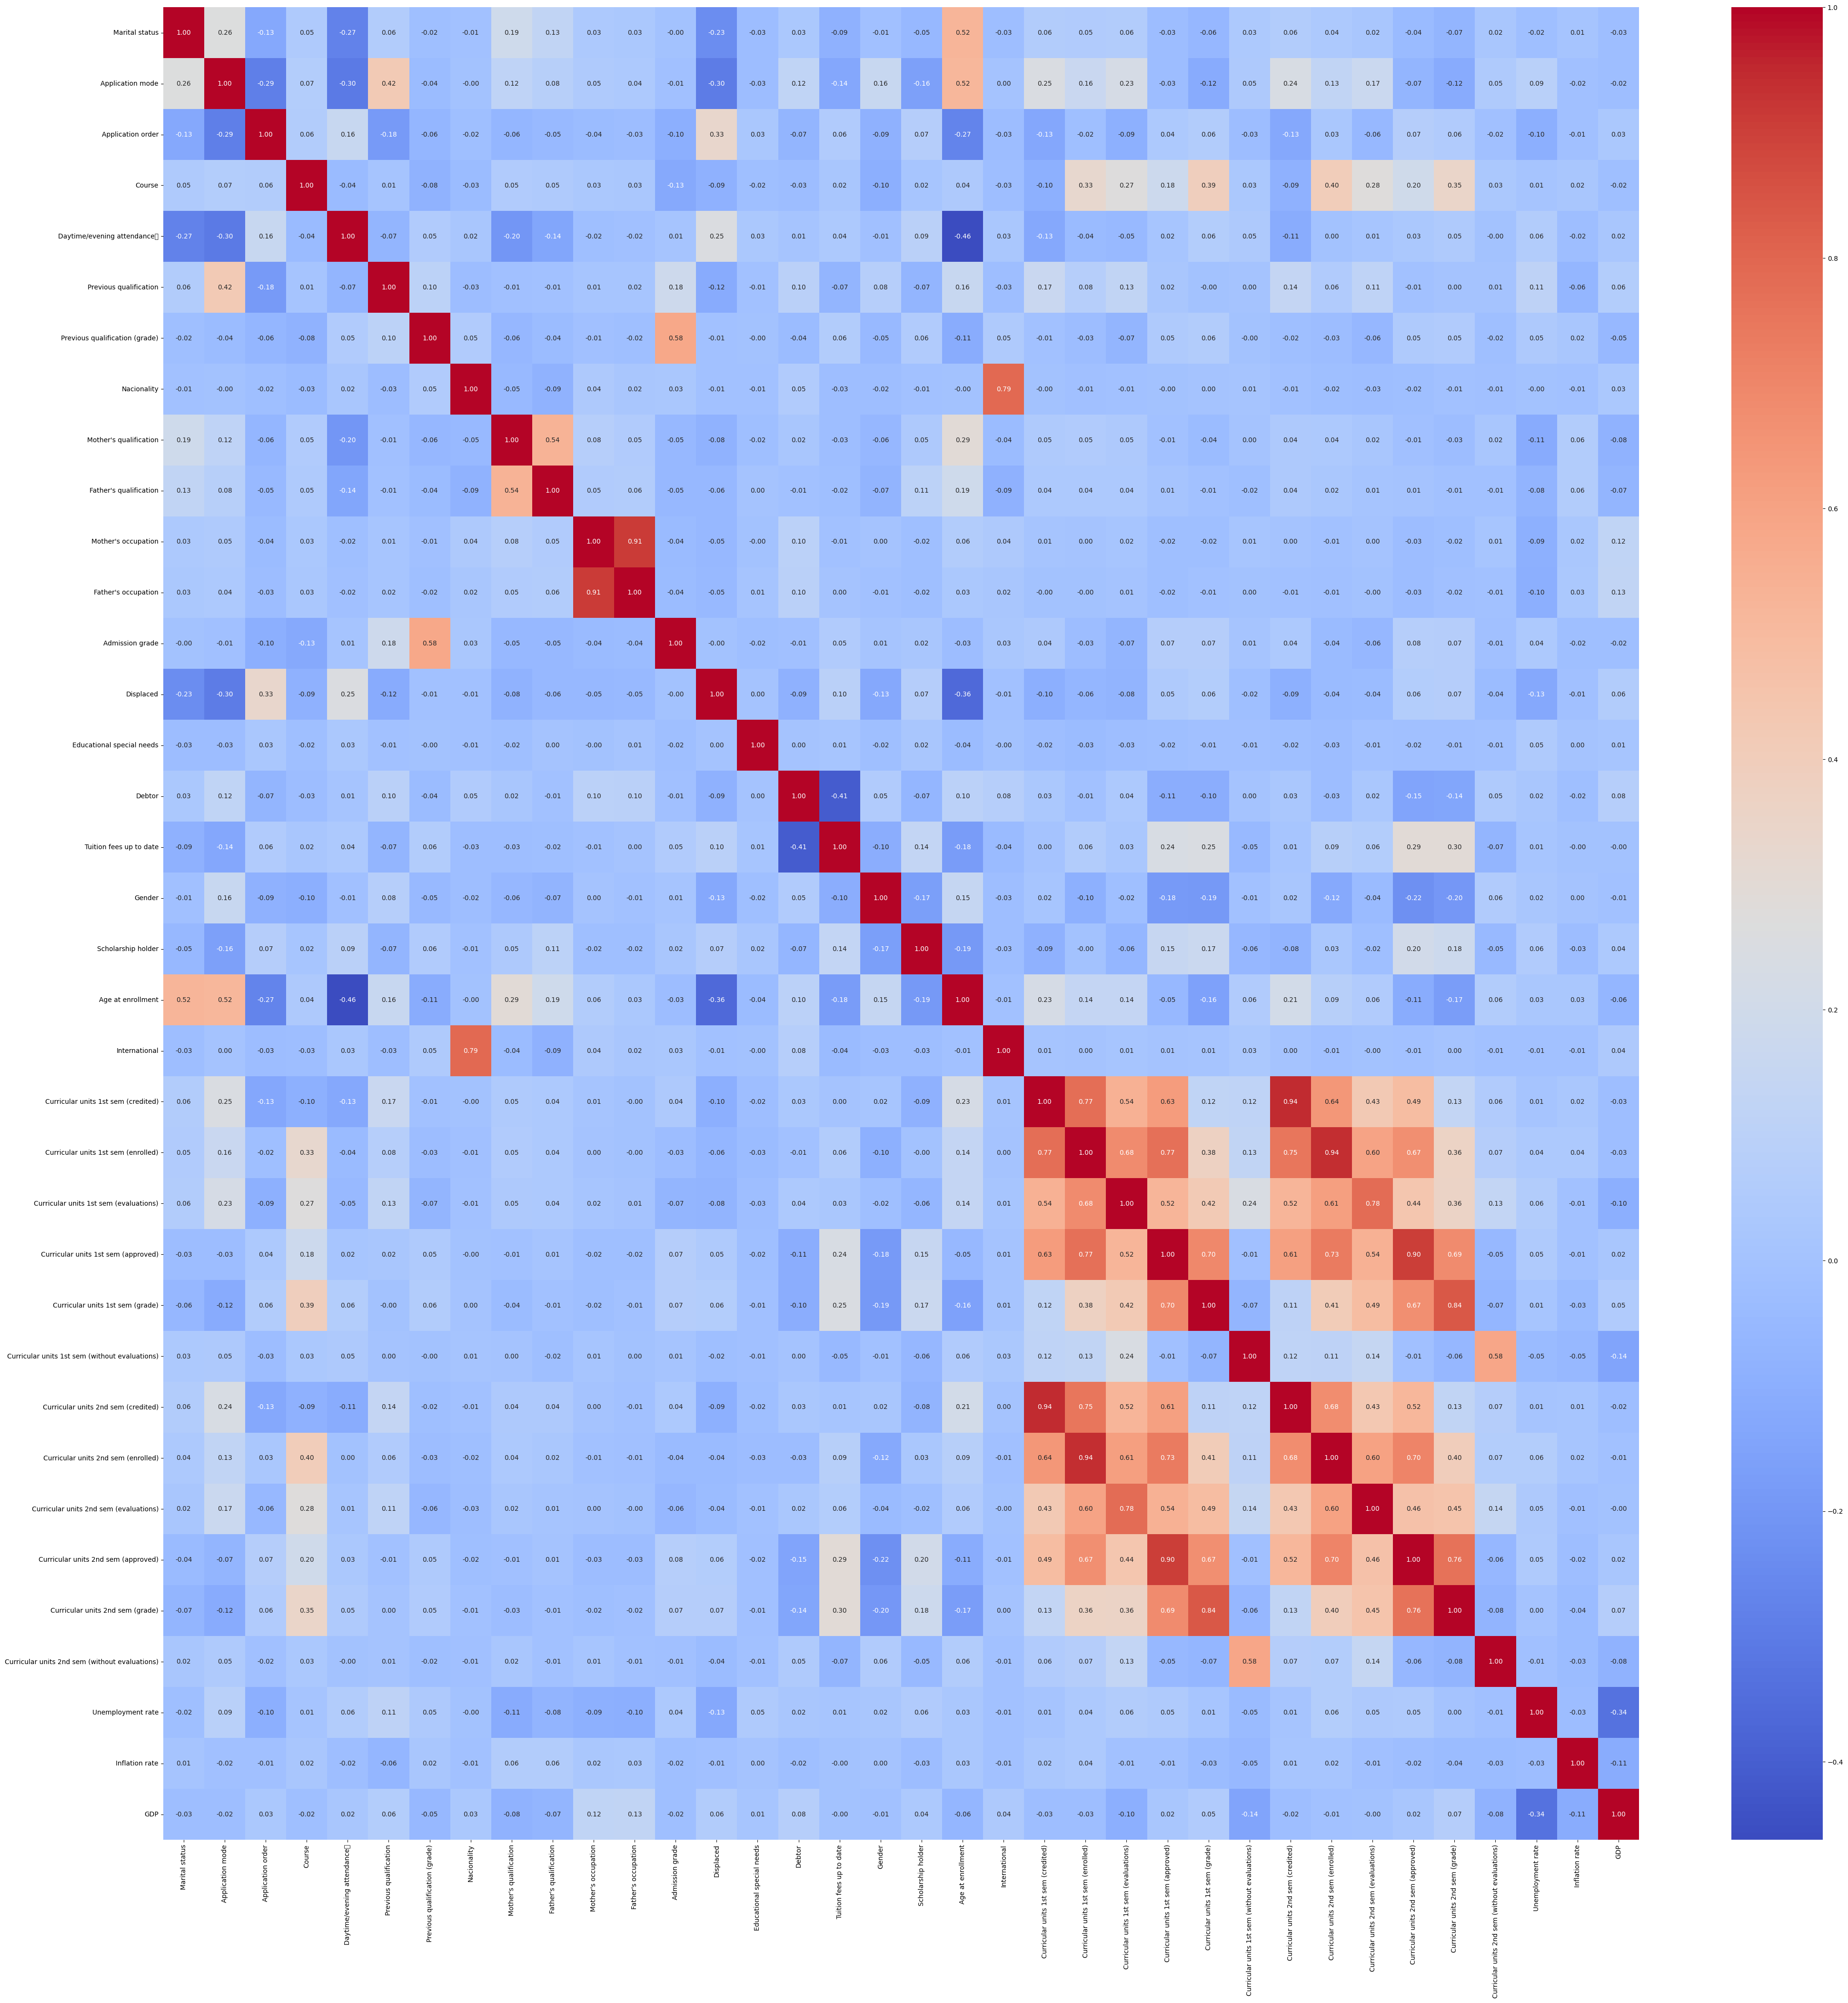

In [20]:
# Draw a heatmap to visualize the correlation matrix
plt.figure(figsize = (50,50))
sns.heatmap(cov, xticklabels=df.columns[:-1], yticklabels=df.columns[:-1], annot=cov, cmap='coolwarm', fmt=".2f")

# Bulding Logistic Regression

In [21]:
x = df.iloc[:, :-1]
x.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,1,17,5,171,1,1,-0.804750,1,19,12,...,0,0,0,0,0,0.000000,0,-0.287606,0.124372,0.765674
1,1,15,1,9254,1,1,2.076585,1,1,3,...,0,0,6,6,6,13.666667,0,0.876123,-1.105097,0.347160
2,1,1,5,9070,1,1,-0.804750,1,37,37,...,0,0,6,0,0,0.000000,0,-0.287606,0.124372,0.765674
3,1,17,2,9773,1,1,-0.804750,1,38,37,...,0,0,6,10,5,12.400000,0,-0.813161,-1.466705,-1.375356
4,2,39,1,8014,0,1,-2.472892,1,37,38,...,0,0,6,6,6,13.000000,0,0.876123,-1.105097,0.347160


In [22]:
y = df.iloc[:, -1]
y.value_counts()

Target
0    2215
1    2209
Name: count, dtype: int64

In [23]:
x = x.to_numpy()
x.shape

(4424, 36)

In [24]:
y = y.to_numpy().reshape(-1, 1)
y.shape

(4424, 1)

# Divide dataset into 3 sections:
- Train
- Dev
- Test

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
x_dev, x_test, y_dev, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f'Train set: {x_train.shape}, {y_train.shape}')
print(f'Dev set: {x_dev.shape}, {y_dev.shape}')
print(f'Test set: {x_test.shape}, {y_test.shape}')


Train set: (3539, 36), (3539, 1)
Dev set: (442, 36), (442, 1)
Test set: (443, 36), (443, 1)


In [31]:
from tqdm import tqdm
class LogisticRegression:
    def __init__(self, epoch: int, lr: float) -> None:
        self.epoch = epoch
        self.lr = lr
        self.losses = []
        self.metrics = []
    
    def sigmoid(self, z: np.ndarray) -> np.ndarray:
        z = np.clip(z, -500, 500) # limit z to avoid overflow
        return 1 / (1 + np.exp(-z))
    
    def loss_fn(self, y: np.ndarray, y_hat: np.ndarray) -> float:
        return -(y * np.log(y_hat + 1e-9) + (1 - y) * np.log(1 - y_hat + 1e-9)).mean()
    
    def accuracy(self, y: np.ndarray, y_hat: np.ndarray) -> float:
        return np.mean(y == y_hat)
    
    def fit(self, x: np.ndarray, y: np.ndarray) -> None:
        n = x.shape[0]
        d = x.shape[1]
        self.theta = np.zeros((d, 1))
        with tqdm (range(self.epoch)) as pb:
            for e in pb:
                # Forward
                pb.set_description(f'Epoch {e + 1}')
                y_hat = self.predict(x)
                
                # Backward
                diff = y_hat - y
                gradient = (1 / n) * np.matmul(x.T, diff) # (d, 1)
                self.theta -= self.lr * gradient
                
                # Evaluate
                y_hat = self.predict(x)
                loss = self.loss_fn(y, y_hat)
                acc = self.accuracy(y, y_hat)
                pb.set_postfix ({
                    'loss': loss,
                    'acc': acc
                })
                
                self.losses.append(loss)
                self.metrics.append(acc)
                
    def predict(self, x: np.ndarray) -> np.ndarray:
        z = np.matmul(x, self.theta) # (n, 1)
        y_hat = self.sigmoid(z) # (n, 1)
        return y_hat

In [33]:
logistic_reg = LogisticRegression(500, 0.01)

In [34]:
logistic_reg.fit(x_train,y_train)

Epoch 4:   0%|          | 0/500 [00:00<?, ?it/s, loss=10.4, acc=0.499]

Epoch 500: 100%|██████████| 500/500 [00:08<00:00, 60.85it/s, loss=10.2, acc=0.482]  


In [36]:
# Predict for train set
y_pred = logistic_reg.predict(x_train)
acc = logistic_reg.accuracy(y_train, y_pred)
print(f"\nTest Accuracy: {acc:.4f}")


Test Accuracy: 0.4818


In [37]:
# Predict for test set
y_pred = logistic_reg.predict(x_test)
acc = logistic_reg.accuracy(y_test, y_pred)
print(f"\nTest Accuracy: {acc:.4f}")


Test Accuracy: 0.4876


In [ ]:
import matplotlib.pyplot as plt

# After training
plt.figure(figsize=(10, 5))
plt.plot(logistic_reg.losses, label='Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()
